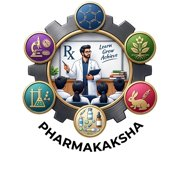

# BP604T · Unit V — AI in Pharmaceutical Analysis and Chemometrics
**Pharmakaksha · Learn · Grow · Achieve**
*AI applications in Pharmaceutical Sciences · B.Pharm Semester VI · PCI NEP 2020*

This notebook contains every example and demo from the Unit V study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit5_AI_in_Pharmaceutical_Analysis.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit5_AI_in_Pharmaceutical_Analysis.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. Real drug names and structures are used only to show how the methods work. The models are for learning AI methods only. They are not quality-control, regulatory or clinical tools.

## 5.1 Chemometrics and multivariate data
**Chemometrics** is the use of mathematics and statistics to extract information from chemical measurements. A spectrum is not one number but hundreds: the absorbance at every wavelength. A set of spectra forms a **data matrix**: one row per sample, one column per wavelength.

`nir_tablets.csv` holds near-infrared (NIR) spectra of 110 fictional tablets, 1100–2500 nm every 10 nm: 70 genuine tablets and 40 counterfeits of three kinds.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
nir = load("nir_tablets.csv")
wcols = [c for c in nir.columns if c.startswith("nm")]
wl_nir = np.array([int(c[2:]) for c in wcols])
S = nir[wcols].values
print("Data matrix:", S.shape, "→", S.shape[0], "tablets ×", S.shape[1], "wavelengths")
print(nir["group"].value_counts())

In [ ]:
colours = {"genuine": "#17725C", "counterfeit_no_api": "#8C2D19", "counterfeit_low_api": "#E07A2E", "counterfeit_starch": "#7A5195"}
plt.figure(figsize=(9, 4.5))
for grp, c in colours.items():
    rows = S[nir["group"] == grp][:8]
    for k, s in enumerate(rows):
        plt.plot(wl_nir, s, color=c, alpha=0.7, linewidth=1, label=grp if k == 0 else None)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Absorbance (log 1/R)")
plt.title("Raw NIR spectra: hard to tell apart by eye"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5.2 UV spectral modelling
`uv_mixtures.csv`: UV spectra (220–320 nm) of 40 fictional mixtures of **paracetamol** (λmax ≈ 243 nm) and **caffeine** (λmax ≈ 273 nm) with known concentrations. The bands overlap, so the absorbance at 243 nm comes from both drugs.

In [ ]:
uv = load("uv_mixtures.csv")
acols = [c for c in uv.columns if c.startswith("A")]
wl_uv = np.array([int(c[1:]) for c in acols])
U = uv[acols].values
# Estimate each drug's "pure" spectrum (absorbance per µg/mL) from the mixtures by least squares
C = uv[["paracetamol_ug_ml", "caffeine_ug_ml"]].values
pure = np.linalg.lstsq(C, U, rcond=None)[0]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(wl_uv, pure[0] * 10, color="#17725C", label="Paracetamol 10 µg/mL")
ax[0].plot(wl_uv, pure[1] * 10, color="#E07A2E", label="Caffeine 10 µg/mL")
ax[0].set_title("Overlapping bands"); ax[0].legend()
for s in U[:6]:
    ax[1].plot(wl_uv, s, color="#12303A", alpha=0.6)
ax[1].set_title("Six mixture spectra")
for a in ax:
    a.set_xlabel("Wavelength (nm)"); a.set_ylabel("Absorbance"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("λmax paracetamol:", wl_uv[np.argmax(pure[0])], "nm;  λmax caffeine:", wl_uv[np.argmax(pure[1])], "nm")

## 5.3 Quantitative regression
### Single drug: a Beer–Lambert calibration
`uv_calibration.csv`: paracetamol standards 2–20 µg/mL, three replicates, absorbance at 243 nm. Following ICH Q2, LOD = 3.3·σ/S and LOQ = 10·σ/S, where S is the slope and σ the residual standard deviation.

In [ ]:
cal = load("uv_calibration.csv")
slope, intercept = np.polyfit(cal["conc_ug_ml"], cal["absorbance_243"], 1)
resid = cal["absorbance_243"] - (intercept + slope * cal["conc_ug_ml"])
sigma = np.sqrt(np.sum(resid ** 2) / (len(cal) - 2))
r = np.corrcoef(cal["conc_ug_ml"], cal["absorbance_243"])[0, 1]
print(f"A = {intercept:.4f} + {slope:.4f} × C     r = {r:.4f}")
print(f"LOD = {3.3 * sigma / slope:.2f} µg/mL   LOQ = {10 * sigma / slope:.2f} µg/mL")
print(f"Unknown with A = 0.512 → {(0.512 - intercept) / slope:.2f} µg/mL")

### Two drugs together: one wavelength, two wavelengths or the whole spectrum
We train on 30 mixtures and test on 10, comparing three approaches for paracetamol:
1. **Univariate**: the pure-paracetamol calibration line above, applied at 243 nm (it ignores caffeine);
2. **Simultaneous equations** (Vierordt's method): absorbance at 243 and 273 nm, solved together (a 2-wavelength linear regression);
3. **PLS regression** (partial least squares) on all 101 wavelengths.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score

train, test = uv.iloc[:30], uv.iloc[30:]
yt, ys = train["paracetamol_ug_ml"], test["paracetamol_ug_ml"]
rmse = lambda a, b: np.sqrt(mean_squared_error(a, b))
results = {}
results["1. Univariate (243 nm)"] = (test["A243"] - intercept) / slope        # Beer–Lambert line from pure standards
m2 = LinearRegression().fit(train[["A243", "A273"]], yt);    results["2. Two wavelengths (243 + 273)"] = m2.predict(test[["A243", "A273"]])
pls = PLSRegression(n_components=3).fit(train[acols], train[["paracetamol_ug_ml", "caffeine_ug_ml"]])
pls_pred = pls.predict(test[acols]);                          results["3. PLS, full spectrum"] = pls_pred[:, 0]
for k, p in results.items():
    print(f"{k:32s} RMSEP = {rmse(ys, p):.3f} µg/mL   mean error (bias) = {np.mean(p - ys):+.3f} µg/mL")
print(f"PLS also predicts caffeine: RMSEP = {rmse(test['caffeine_ug_ml'], pls_pred[:, 1]):.3f} µg/mL")

In [ ]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(ys, results["1. Univariate (243 nm)"], color="#E07A2E", label="Univariate 243 nm")
plt.scatter(ys, results["3. PLS, full spectrum"], color="#17725C", label="PLS")
plt.plot([3, 17], [3, 17], color="grey", linestyle="--")
plt.xlabel("True paracetamol (µg/mL)"); plt.ylabel("Predicted (µg/mL)")
plt.title("Test mixtures: PLS removes the caffeine interference"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5.4 Chromatographic peak modelling
`hplc_run.csv` is one fictional HPLC run (UV detector, 0–10 min) with impurity A, the API and two more impurities. We correct the baseline, find the peaks, and measure them:
- **Plate number** N = 5.54·(t_R / W½)², where W½ is the peak width at half height;
- **Resolution** R_s = 1.18·(t₂ − t₁)/(W½,₁ + W½,₂); R_s ≥ 2 is usually required;
- **Area** for quantification (area %).

In [ ]:
from scipy.signal import find_peaks, peak_widths, savgol_filter
hp = load("hplc_run.csv")
t, sig = hp["time_min"].values, hp["signal_mAU"].values
quiet = (t < 2.5) | ((t > 5.5) & (t < 6.4)) | (t > 7.5)        # regions with no peaks
base = np.polyval(np.polyfit(t[quiet], sig[quiet], 1), t)
y = savgol_filter(sig - base, 11, 3)                            # baseline-corrected and smoothed
pk, _ = find_peaks(y, height=5, prominence=4)
w = peak_widths(y, pk, rel_height=0.5)[0] * (t[1] - t[0])      # width at half height, minutes
table = pd.DataFrame({"t_R (min)": t[pk], "height (mAU)": y[pk].round(1), "W½ (min)": w.round(3)})
table["N (plates)"] = (5.54 * (table["t_R (min)"] / table["W½ (min)"]) ** 2).round(0)
table["R_s to next"] = list((1.18 * np.diff(t[pk]) / (w[:-1] + w[1:])).round(2)) + [np.nan]
table

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, sig, color="#B0B8BB", linewidth=0.8, label="Raw signal")
ax.plot(t, y, color="#12303A", linewidth=1.3, label="Baseline-corrected, smoothed")
ax.plot(t[pk], y[pk], "v", color="#E07A2E", markersize=9, label="Peaks found")
ax.set_xlim(2.5, 7.5); ax.set_ylim(-5, 60)
ax.set_xlabel("Time (min)"); ax.set_ylabel("Signal (mAU)")
ax.set_title("HPLC run (zoomed so the small impurity peaks are visible; the API peak goes off-scale)")
ax.legend(); ax.grid(alpha=0.3); plt.show()

In [ ]:
# The API (4.20 min) and impurity B (4.42 min) overlap. Model the pair as two Gaussian peaks.
from scipy.optimize import curve_fit
def two_gauss(x, h1, c1, s1, h2, c2, s2):
    return h1 * np.exp(-0.5 * ((x - c1) / s1) ** 2) + h2 * np.exp(-0.5 * ((x - c2) / s2) ** 2)
win = (t > 3.9) & (t < 4.75)
par, _ = curve_fit(two_gauss, t[win], y[win], p0=[400, 4.2, 0.06, 25, 4.42, 0.05])
h1, c1, s1, h2, c2, s2 = par
area_api, area_b = h1 * abs(s1) * np.sqrt(2 * np.pi), h2 * abs(s2) * np.sqrt(2 * np.pi)
print(f"API peak at {c1:.2f} min, impurity B at {c2:.2f} min")
print(f"Impurity B = {100 * area_b / (area_api + area_b):.1f}% of the pair's area")
print(f"Resolution from the fitted peaks: R_s = {1.18 * (c2 - c1) / (2.355 * (abs(s1) + abs(s2))):.2f}")

## 5.5 Genuine vs counterfeit detection
NIR spectra are affected by **light scattering** (particle size, tablet surface). The **SNV** (standard normal variate) transform removes most of it: each spectrum is centred on its own mean and divided by its own standard deviation. Then **PCA** (principal component analysis) squeezes 141 wavelengths into a few scores we can plot.

In [ ]:
from sklearn.decomposition import PCA
def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)
Z = snv(S)
pca = PCA(n_components=5).fit(Z)
scores = pca.transform(Z)
print("Variance explained by PC1–PC5:", (pca.explained_variance_ratio_ * 100).round(1))
plt.figure(figsize=(7.5, 5.5))
for grp, c in colours.items():
    m = nir["group"] == grp
    plt.scatter(scores[m, 0], scores[m, 1], color=c, label=grp, s=30, alpha=0.85)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA scores after SNV: genuine tablets form one tight group")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:
# Supervised: PCA scores + logistic regression, trained on a random 70% of tablets
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
yN = (nir["label"] == "counterfeit").astype(int).values
Z_tr, Z_te, y_tr, y_te, g_tr, g_te = train_test_split(Z, yN, nir["group"].values, test_size=0.3, random_state=5, stratify=nir["group"])
clf = make_pipeline(PCA(n_components=5), LogisticRegression(max_iter=1000)).fit(Z_tr, y_tr)
print("Test accuracy:", round(accuracy_score(y_te, clf.predict(Z_te)), 3))
print(confusion_matrix(y_te, clf.predict(Z_te)))

In [ ]:
# One-class model: learn ONLY what genuine tablets look like, flag anything too far away.
# This can catch a counterfeit type the model has never seen.
gen_tr = Z_tr[g_tr == "genuine"]
pca_g = PCA(n_components=3).fit(gen_tr)
def distance(X):
    sc = pca_g.transform(X)
    t2 = np.sum(sc ** 2 / pca_g.explained_variance_, axis=1)                 # Hotelling T²
    q = np.sum((X - pca_g.inverse_transform(sc)) ** 2, axis=1)              # Q residual
    return t2 / np.percentile(t2_ref, 99) + q / np.percentile(q_ref, 99)
sc_ref = pca_g.transform(gen_tr)
t2_ref = np.sum(sc_ref ** 2 / pca_g.explained_variance_, axis=1)
q_ref = np.sum((gen_tr - pca_g.inverse_transform(sc_ref)) ** 2, axis=1)
limit = np.percentile(distance(gen_tr), 99)
flag = distance(Z_te) > limit
print(pd.Series(flag, index=g_te).groupby(level=0).mean().round(2).rename("share flagged as not genuine"))

The low-dose fakes (80% of the API) look **almost identical** to genuine tablets, so the identity screen misses them. A **quantitative** model is needed: PLS regression of the API content (% of label claim) on the SNV spectra.

In [ ]:
api = nir["api_pct_label"].values
a_tr, a_te = train_test_split(api, test_size=0.3, random_state=5, stratify=nir["group"])
pls_api = PLSRegression(n_components=4).fit(Z_tr, a_tr)
a_pred = pls_api.predict(Z_te).ravel()
print(f"API content: RMSEP = {rmse(a_te, a_pred):.1f}% of label claim")
print(pd.Series(a_pred, index=g_te).groupby(level=0).mean().round(1).rename("mean predicted API %"))

## 5.6 Noise and variability
Every measurement contains **noise** (random) and **variability** (systematic shifts between instruments, days, operators, batches). Common tools:
- **Smoothing** (Savitzky–Golay) reduces random noise but can broaden narrow peaks if overdone;
- **SNV and derivatives** remove scatter and baseline shifts in spectra;
- **Replicates** measure repeatability (relative standard deviation, %RSD).

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for s in S[nir["group"] == "genuine"][:10]:
    ax[0].plot(wl_nir, s, color="#17725C", alpha=0.6)
for s in Z[nir["group"] == "genuine"][:10]:
    ax[1].plot(wl_nir, s, color="#17725C", alpha=0.6)
ax[0].set_title("10 genuine tablets: raw (scatter shifts)"); ax[1].set_title("Same tablets after SNV")
for a in ax:
    a.set_xlabel("Wavelength (nm)"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Smoothing: how much noise is removed, and what happens if we over-smooth?
seg = (t > 7.6) & (t < 10)                                        # baseline only: pure noise
print("Noise SD, raw:", round((sig - base)[seg].std(), 3), " smoothed:", round(y[seg].std(), 3), "mAU")
for wlen in [11, 51, 151]:
    ys_ = savgol_filter(sig - base, wlen, 3)
    print(f"Window {wlen:3d} points → API peak height {ys_[np.argmin(abs(t - 4.2))]:.0f} mAU")
# Repeatability of the calibration standards
rsd = cal.groupby("conc_ug_ml")["absorbance_243"].agg(lambda a: 100 * a.std() / a.mean())
print("%RSD of triplicates:", rsd.round(2).to_dict())

## 5.7 Limitations
- **Calibration transfer:** a model built on one spectrometer often fails on another, or after a lamp change.
- **Representative samples:** calibration sets must cover the real range of concentrations, excipients, particle sizes and temperatures.
- **Over-fitting:** too many PLS components fit noise. Choose them by cross-validation.
- **Unknown counterfeits:** a supervised classifier only knows the fakes it was trained on; one-class models help but need a reference library of genuine product.
- **Confirmation:** a chemometric screen is a fast first check. Regulatory decisions need validated reference methods (e.g. HPLC).

## Worked example: screening tablets seized from the market
Five suspect tablets (from the test set, never used for training) are scanned with a handheld NIR. A tablet passes only if it is close to the genuine group (one-class distance) **and** its predicted API content is 90–110% of label claim.

In [ ]:
pick = [list(g_te).index(gname) for gname in ["genuine", "counterfeit_low_api", "counterfeit_starch", "counterfeit_no_api"]]
pick.append([i for i, gname in enumerate(g_te) if gname == "genuine"][1])
suspects = Z_te[pick]
d = distance(suspects)
api_hat = pls_api.predict(suspects).ravel()
ok = (d <= limit) & (api_hat >= 90) & (api_hat <= 110)
pd.DataFrame({"true group (hidden in practice)": g_te[pick], "distance": d.round(2), "predicted API %": api_hat.round(0),
              "decision": np.where(ok, "Consistent with genuine", "Suspect: send for HPLC")})

## Quick check
A PLS model built on one NIR instrument gives assay values 4% too high on a second instrument. Is the model wrong, or is something else going on? Decide, then run the cell.

In [ ]:
print("The model may be fine for its own instrument. The two instruments differ (wavelength shift, detector response): calibration transfer or a new model is needed.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Using `uv_calibration.csv`, compute the slope using only replicate 1. How close is it to the slope from all three replicates?

**2.** Refit the PLS model with 1, 2 and 5 components. Which number gives the lowest RMSEP for paracetamol?

**3.** Find the retention time and plate number of the largest peak in `hplc_run.csv`.

**4.** Repeat the PCA in section 5.5 **without** SNV. Are genuine and counterfeit tablets still well separated on PC1 and PC2?

---
## Solutions

In [ ]:
# 1
c1 = cal[cal["replicate"] == 1]
print("Replicate 1 slope:", round(np.polyfit(c1["conc_ug_ml"], c1["absorbance_243"], 1)[0], 4), " all:", round(slope, 4))

In [ ]:
# 2
for k in [1, 2, 3, 5]:
    p = PLSRegression(n_components=k).fit(train[acols], train[["paracetamol_ug_ml", "caffeine_ug_ml"]]).predict(test[acols])[:, 0]
    print(k, "components: RMSEP =", round(rmse(ys, p), 3))

In [ ]:
# 3
big = table.loc[table["height (mAU)"].idxmax()]
print("t_R =", big["t_R (min)"], "min,  N =", int(big["N (plates)"]))

In [ ]:
# 4
raw_scores = PCA(n_components=2).fit_transform(S - S.mean(axis=0))
for grp, c in colours.items():
    m = nir["group"] == grp
    plt.scatter(raw_scores[m, 0], raw_scores[m, 1], color=c, label=grp, s=20)
plt.legend(); plt.title("Without SNV: scatter dominates PC1"); plt.show()

---
**BP604T complete.** Next subject: BP701T Biostatistics and Research Methodology. Pharmakaksha · Learn · Grow · Achieve